# Butler — Agent-Analyse

Test-Notebook fuer den Butler-Agent. Nutzt das wiederverwendbare
`analysis_lib` und liest Szenarien aus `scenarios/butler.yaml`.

**Modi:**
- **`light`** (default): reduzierter Tool-Set ohne OAuth/Telegram/Sub-Agents.
  Laeuft ueberall, ca. 14 der 22 Szenarien testbar.
- **`full`**: Profile `butler` mit allen 12 Tools + 5 Sub-Agents.
  Braucht `~/.taskforce/google_token.json` und Gateway-Setup.

**Tracking:** Context-Last, Tool-Frequenz, Plan, Skill-Injection, Datei-Diff,
Pre/Post-Sanity, plus 5 Auswerte-Diagramme.

**Inspiration:**
- pi-Bench (proactive personal assistant, hidden intents)
- ClawsBench (productivity workspace simulation)
- Realer Butler-Use-Case + Pain Points aus `memory/user_butler_usage.md`


## 1. Setup


In [1]:
import os, sys, importlib
from pathlib import Path

PYTF_ROOT = Path.cwd()
if PYTF_ROOT.name == 'notebooks':
    PYTF_ROOT = PYTF_ROOT.parent
os.chdir(PYTF_ROOT)
for p in [str(PYTF_ROOT / 'src'), str(PYTF_ROOT / 'notebooks')]:
    if p not in sys.path:
        sys.path.insert(0, p)

try:
    from dotenv import load_dotenv
    load_dotenv(PYTF_ROOT / '.env')
except ImportError:
    pass

try:
    import nest_asyncio; nest_asyncio.apply()
except ImportError:
    pass

import logging, structlog
logging.basicConfig(level=logging.WARNING, format='%(levelname)s %(name)s | %(message)s')
structlog.configure(wrapper_class=structlog.make_filtering_bound_logger(logging.WARNING))

# Reload analysis_lib at every setup run — picks up edits without kernel restart.
import analysis_lib
importlib.reload(analysis_lib)
import analysis_lib as alib

print('analysis_lib OK')
print(f'  pytaskforce: {PYTF_ROOT}')
print(f'  alib symbols: {len([s for s in dir(alib) if not s.startswith(chr(95))])} public')


analysis_lib OK
  pytaskforce: C:\Users\rudi\source\pytaskforce
  alib symbols: 44 public


In [2]:
# === Mode flag - light or full ===
MODE = 'light'   # 'light' (default) | 'full'

# Light: reduzierter Tool-Set, kein OAuth, keine Sub-Agents
LIGHT_TOOLS = [
    'file_read', 'wiki', 'web_search', 'web_fetch',
    'reminder', 'schedule', 'ask_user', 'activate_skill',
]

# Butler-Work-Dir (separat von TuttiPaletti, damit nichts kollidiert)
BUTLER_WORKDIR = Path(r'.taskforce_butler_analysis')
BUTLER_WORKDIR.mkdir(exist_ok=True)
print(f'MODE={MODE}, work_dir={BUTLER_WORKDIR.resolve()}')


MODE=light, work_dir=C:\Users\rudi\source\pytaskforce\.taskforce_butler_analysis


## 2. Butler-Agent bauen

Zwei Wege:
- **Light** baut programmatisch mit reduziertem Tool-Set
- **Full** laedt das Profile `butler` (alle 12 Tools + Sub-Agents)

Beide patchen die Compression/Tool-Store-Thresholds via
`alib.patch_anti_compression()` damit parallele Tool-Nutzung nicht in eine
Compression-Schleife laeuft.


In [3]:
from taskforce.application.factory import AgentFactory
from taskforce.application.executor import AgentExecutor
from taskforce.infrastructure.scheduler.scheduler_service import SchedulerService

factory = AgentFactory()
executor = AgentExecutor(factory=factory)

# Scheduler initialisieren - reminder + schedule Tools brauchen ihn.
scheduler = SchedulerService(work_dir=str(BUTLER_WORKDIR))
await scheduler.start()
factory.set_scheduler(scheduler)

# P1: Post-mission-learning hard-disable. Der Executor liest sonst
# learning.enabled aus default.yaml (true) und schreibt nach jeder Mission
# heimlich Wiki-Pages. Im Analyse-Setup wollen wir nur Agent-Verhalten messen.
alib.disable_post_mission_learning(executor)

# P2: erweiterter Light-System-Prompt mit konkreten schedule-Beispielen +
# single-source-vs-multi-source Heuristik (aus voller CLAUDE.md verkleinert).
BUTLER_SYSTEM_PROMPT_LIGHT = (
    "Du bist ein persoenlicher Butler-Assistent. Halte dich kurz, antworte direkt. "
    "Auf Deutsch. Bei Aktionen, die du nicht ausfuehren kannst (z.B. WhatsApp, SMS, "
    "Anrufe, Apps auf dem Handy, Drucken) - sag es offen in der ersten Antwort.\n\n"
    "Tools: file_read, wiki, web_search, web_fetch, reminder, schedule, ask_user. "
    "Skills via activate_skill.\n\n"
    "=== SCHEDULE-TOOL ===\n"
    "Statisch (Text der gleich bleibt) -> schedule(action_type=send_notification, "
    "action_params={message: \'...\'}):\n"
    "  Beispiel: \'jeden Morgen 8:00 Guten-Morgen-Nachricht\' \n"
    "  -> schedule(name=\'morgengruss\', schedule_type=cron, expression=\'0 8 * * *\', "
    "action_type=send_notification, action_params={message: \'Guten Morgen Rudi\'})\n"
    "Dynamisch (Wert aendert sich, z.B. Kurs/Wetter/News) -> schedule(action_type=execute_mission, "
    "action_params={mission: \'...\'}):\n"
    "  Beispiel: \'alle 30 Min Bitcoin-Kurs pushen\' \n"
    "  -> schedule(name=\'btc-kurs\', schedule_type=interval, expression=\'30m\', "
    "action_type=execute_mission, action_params={mission: \'Hole aktuellen Bitcoin-Kurs via web_fetch "
    "und sende als Push: \\\'BTC: $X\\\'\'})\n"
    "Bei action_type=send_notification ist action_params.message PFLICHT.\n\n"
    "=== WEB-TOOLS ===\n"
    "Single-source factual (Wetter, ein Kurs, eine Zahl, eine News-Headline) "
    "-> DIREKT web_fetch nutzen. KEINE Multi-source-Recherche dafuer!\n"
    "Multi-source Vergleich/Briefing -> web_search erst, dann web_fetch der Top-Treffer.\n"
    "Web-Tools max 3-5 Aufrufe pro Frage. Mehr nur bei explizitem Vergleichswunsch.\n\n"
    "=== WIKI ===\n"
    "Wiki nutzen fuer reusable info (Praeferenzen, Kontakte, Workflows). "
    "NICHT fuer transiente Werte (Uhrzeit, einmalige Tasks).\n\n"
    "=== ANTWORT-STIL ===\n"
    "- Nie \'Erledigt.\' oder \'Execution completed.\' als Antwort.\n"
    "- Immer sagen WAS du gemacht hast, mit konkreten Werten.\n"
    "- Reminder bestaetigen mit absolutem Zeitpunkt UND relativem Hinweis "
    "(\'um 14:30 Uhr / in 2 Stunden\')."
)

async def build_light_agent():
    a = await factory.create_agent(
        system_prompt=BUTLER_SYSTEM_PROMPT_LIGHT,
        tools=LIGHT_TOOLS,
        persistence={'type': 'file', 'work_dir': str(BUTLER_WORKDIR)},
        work_dir=str(BUTLER_WORKDIR),
        planning_strategy='plan_and_react',
        planning_strategy_params={'max_plan_steps': 8},
        max_steps=15,
    )
    alib.patch_anti_compression(a, summary_threshold=80, tool_result_store_threshold=6000)
    alib.patch_notification_defaults(a)
    return a, len(BUTLER_SYSTEM_PROMPT_LIGHT)

async def build_full_agent():
    a = await factory.create_agent(profile='butler')
    alib.patch_anti_compression(a, summary_threshold=80, tool_result_store_threshold=6000)
    alib.patch_notification_defaults(a)
    sys_chars = sum(
        len(str(m.get('content',''))) for m in a.context.messages if m.get('role')=='system'
    )
    return a, sys_chars

BUILD_AGENT = build_full_agent if MODE == 'full' else build_light_agent

# Smoke build mit detaillierter Tool-Diagnose
_smoke, _chars = await BUILD_AGENT()
AVAILABLE_TOOLS = set(_smoke.tools.keys())

print(f'Butler ({MODE}) OK')
print(f'  Tools         : {sorted(AVAILABLE_TOOLS)}')
print(f'  System-Prompt : {_chars} chars')
print(f'  Strategy      : {_smoke.planning_strategy.name}')
print(f'  Max steps     : {_smoke.max_steps}')
print(f'  summary_thr   : {_smoke.message_history_manager._summary_threshold}')
print(f'  result_store  : {_smoke.tool_executor._result_store_threshold}')
print(f'  scheduler     : running={scheduler.is_running}, jobs={len(scheduler._jobs)}')
print(f'  learning      : disabled (executor patched)')

print()
print('=== Notification-Tool Diagnose ===')
for _name in ('reminder', 'schedule', 'send_notification'):
    _t = _smoke.tools.get(_name)
    if _t is None:
        print(f'  {_name:18s}: NOT IN TOOLS')
        continue
    _cls = type(_t).__name__
    _wrapped = type(getattr(_t, '_original', None)).__name__ if hasattr(_t, '_original') else None
    _target = getattr(_t, '_original', _t)
    _rid = getattr(_target, '_default_recipient_id', 'NO_ATTR')
    _ch = getattr(_target, '_default_channel', 'NO_ATTR')
    _info = f'cls={_cls}'
    if _wrapped:
        _info += f' wraps={_wrapped}'
    print(f'  {_name:18s}: {_info}')
    print(f'  {"":18s}    channel={_ch!r}, recipient={_rid!r}')

await _smoke.close()


Butler (light) OK
  Tools         : ['activate_skill', 'ask_user', 'file_read', 'planner', 'reminder', 'schedule', 'web_fetch', 'web_search', 'wiki']
  System-Prompt : 1824 chars
  Strategy      : plan_and_react
  Max steps     : 15
  summary_thr   : 80
  result_store  : 6000
  scheduler     : running=True, jobs=0
  learning      : disabled (executor patched)

=== Notification-Tool Diagnose ===
  reminder          : cls=ReminderTool
                        channel='telegram', recipient='analysis-test'
  schedule          : cls=ScheduleTool
                        channel='NO_ATTR', recipient='NO_ATTR'
  send_notification : NOT IN TOOLS


## 3. Szenarien laden + filtern

Filter: nur Szenarien deren `requires:` Subset der verfuegbaren Tools sind
werden ausgefuehrt. Im Light-Modus heisst das: alles was `gmail`/`calendar`/
`google_drive` braucht, faellt raus.


In [4]:
all_scenarios = alib.load_scenarios('notebooks/scenarios/butler.yaml')
eligible = alib.filter_scenarios(all_scenarios, AVAILABLE_TOOLS)

print(f'Total scenarios       : {len(all_scenarios)}')
print(f'Eligible for {MODE}    : {len(eligible)}')
print(f'Filtered out          : {len(all_scenarios) - len(eligible)}')

print('\nEligible:')
for s in eligible:
    print(f'  {s.id:30s}  ({s.category:8s} / {s.difficulty})')

skipped = [s for s in all_scenarios if s not in eligible]
if skipped:
    print('\nSkipped (requires not satisfied):')
    for s in skipped:
        missing = set(s.requires) - AVAILABLE_TOOLS
        print(f'  {s.id:30s}  needs: {sorted(missing)}')


Total scenarios       : 22
Eligible for light    : 14
Filtered out          : 8

Eligible:
  reminder-simple-2h              (reminder / easy)
  reminder-tomorrow-morning       (reminder / easy)
  schedule-recurring-static       (schedule / medium)
  schedule-recurring-dynamic      (schedule / hard)
  wiki-save-preference            (memory   / easy)
  wiki-save-contact               (memory   / medium)
  memory-recall-after-save        (memory   / medium)
  wiki-no-save-transient          (memory   / medium)
  web-single-fact                 (web      / easy)
  web-research-multi-source       (web      / hard)
  web-news-today                  (web      / easy)
  trap-capability-claim           (trap     / medium)
  trap-overhead-simple            (trap     / easy)
  email-find-address              (email    / medium)

Skipped (requires not satisfied):
  trap-action-gap-status-only     needs: ['gmail']
  cal-today-events                needs: ['calendar']
  cal-create-event           

## 4. Einzelnes Szenario (Detail-Lauf)

Picke ein Szenario fuers Debug-Tracking. Vor und nach dem Lauf wird der
Wiki-Folder snapshottet, damit `file_diff_report` zeigt was tatsaechlich
geschrieben wurde.


In [5]:
TARGET_SCENARIO_ID = 'reminder-simple-2h'   # change me

target = next((s for s in eligible if s.id == TARGET_SCENARIO_ID), None)
if target is None:
    print(f'WARNING: {TARGET_SCENARIO_ID} nicht in eligible - faelle zurueck auf erstes.')
    target = eligible[0]

print(f'Target  : {target.id}')
print(f'Cat/Diff: {target.category} / {target.difficulty}')
print(f'Mission : {target.mission}')
print(f'Expected: {target.expected}')
if target.hidden_intent:
    print(f'Hidden  : {target.hidden_intent}')


Target  : reminder-simple-2h
Cat/Diff: reminder / easy
Mission : Erinnere mich in 2 Stunden ans Frühstück.
Expected: {'must_succeed_tools': ['reminder'], 'must_not_call_tools': ['calendar', 'gmail', 'web_search'], 'final_answer_contains': [['Frühstück', 'Erinnerung', 'erinnern'], ['2 Stunden', 'zwei Stunden', ' Uhr', 'heute um', ':']], 'final_answer_must_not_contain': ['Execution completed', 'Status: completed']}


In [6]:
# Wiki snapshot dirs unter dem Butler-WorkDir
SNAP_DIRS = ('memory', 'memory/wiki')

butler_agent, sys_chars = await BUILD_AGENT()
rec = await alib.run(
    executor, butler_agent, target.mission,
    project_root=BUTLER_WORKDIR,
    snapshot_subdirs=SNAP_DIRS,
    initial_system_prompt_chars=sys_chars,
    max_print_events=30,
)
alib.print_summary(rec)


[tool_call     ] Calling: reminder
args: {
  "remind_at": "2026-05-17T20:35:00+02:00",
  "message": "Frühstück",
  "channel": "telegram"
}
[tool_result   ] OK reminder:
{"success": true, "job_id": "262a872556544dbc9879233b9a554b88", "remind_at": "2026-05-17T20:35:00+02:00", "message": "Reminder set for 2026-05-17T20:35:00+02:00: Fr\u00fchst\u00fcck"}


[tool_call     ] Calling: planner
args: {
  "action": "mark_done",
  "step_index": 1
}
[tool_result   ] OK planner:
[x] 1. {'step': 'Erinnerungszeit berechnen: in 2 Stunden = heute um 20:35 Uhr.', 'status': 'pending'}
[ ] 2. {'step': 'Erinnerung ans Frühstück für 20:35 Uhr anlegen.', 'status': 'pending'}


[tool_call     ] Calling: planner
args: {
  "action": "mark_done",
  "step_index": 2
}
[tool_result   ] OK planner:
[x] 1. {'step': 'Erinnerungszeit berechnen: in 2 Stunden = heute um 20:35 Uhr.', 'status': 'pending'}
[x] 2. {'step': 'Erinnerung ans Frühstück für 20:35 Uhr anlegen.', 'status': 'pending'}


[final_answer  ] Ich habe dir die Erinnerung für **heute um 20:35 Uhr** gesetzt, also **in 2 Stunden**.  
Nachricht: **„Frühstück“**.
[complete      ] Execution completed. Status: completed

Duration: 6.2s | Steps (Bursts): 3 | LLM-Calls: 4 | Tool calls: 3

Final answer (first 800 chars):

Ich habe dir die Erinnerung für **heute um 20:35 Uhr** gesetzt, also **in 2 Stunden**.  
Nachricht: **„Frühstück“**.


## 5. Reports


In [7]:
alib.print_tool_stats(rec)
alib.print_plan_history(rec)


Tool-Aufrufe (Haeufigkeit):
  planner          2x
  reminder         1x

Total Events:                       7
Plan-Snapshots (planner-Tool):      2

--- Letzter Plan-Snapshot ---
[x] 1. {'step': 'Erinnerungszeit berechnen: in 2 Stunden = heute um 20:35 Uhr.', 'status': 'pending'}
[x] 2. {'step': 'Erinnerung ans Frühstück für 20:35 Uhr anlegen.', 'status': 'pending'}


In [8]:
alib.print_context_evolution(rec)


 t [s]  step event          tool         note                                                        
----------------------------------------------------------------------------------------------------
  4.03     0 tool_call      reminder     {"remind_at": "2026-05-17T20:35:00+02:00", "message": "Frühs
  4.03     0 tool_result    reminder     OK | out   183 chars | sum    183
  4.68     0 tool_call      planner      {"action": "mark_done", "step_index": 1}
  4.68     0 tool_result    planner      OK | out   189 chars | sum    372
  5.55     0 tool_call      planner      {"action": "mark_done", "step_index": 2}
  5.55     0 tool_result    planner      OK | out   189 chars | sum    561
  6.23     0 final_answer                Ich habe dir die Erinnerung für **heute um 20:35 Uhr** geset


In [9]:
alib.print_tool_results(rec, head=20)



  -> reminder({"remind_at": "2026-05-17T20:35:00+02:00", "message": "Frühstück", "channel": "telegram"})
     OK: {"success": true, "job_id": "262a872556544dbc9879233b9a554b88", "remind_at": "2026-05-17T20:35:00+02:00", "message": "Reminder set for 2026-05-17T20:35:00+02:00: Fr\u00fchst\u00fcck"}

  -> planner({"action": "mark_done", "step_index": 1})
     OK: [x] 1. {'step': 'Erinnerungszeit berechnen: in 2 Stunden = heute um 20:35 Uhr.', 'status': 'pending'} [ ] 2. {'step': 'Erinnerung ans Frühstück für 20:35 Uhr anlegen.', 'status': 'pending'}

  -> planner({"action": "mark_done", "step_index": 2})
     OK: [x] 1. {'step': 'Erinnerungszeit berechnen: in 2 Stunden = heute um 20:35 Uhr.', 'status': 'pending'} [x] 2. {'step': 'Erinnerung ans Frühstück für 20:35 Uhr anlegen.', 'status': 'pending'}


In [10]:
alib.print_context_view(butler_agent, rec)


=== Snapshot (Token-View) ===
  total_tokens        :   3258
  max_tokens          : 100000
  utilization         :    3.3%
  system_prompt     :   1 items  (  948 tokens)
  messages          :   8 items  (  304 tokens)
  memory            :   0 items  (    0 tokens)
  skills            :   0 items  (    0 tokens)
  tools             :   9 items  ( 2006 tokens)
  sub_agents          :   0

=== Raw Messages ===
  9 messages, 4515 chars total
    assistant   4 msgs      128 chars
    system      1 msgs     3795 chars
    tool        3 msgs      551 chars
    user        1 msgs       41 chars

=== Skill-Injection ===
  System initial      :   1824 chars
  System jetzt        :   3795 chars
  Delta               : ++1971 chars
  activate_skill      : 0x


In [11]:
alib.print_sanity_check(rec)

# Plus: rule-based scoring fuer dieses Szenario
card = alib.score_rule_based(rec, target)
print(f'\n=== Rule-based Score ===')
print(f'  must_call           : {"OK" if card.must_call_tools_pass else "FAIL"}')
print(f'  must_not_call       : {"OK" if card.must_not_call_tools_pass else "FAIL"}')
print(f'  answer_contains     : {"OK" if card.answer_contains_pass else "FAIL"}')
print(f'  answer_forbidden    : {"OK" if card.answer_forbidden_pass else "FAIL"}')
print(f'  overall             : {"PASS" if card.passed else "FAIL"}')
if card.details:
    print(f'  details:')
    for d in card.details:
        print(f'    - {d}')


=== Datei-Diff ===
  NEU geschrieben   :  0
  MODIFIZIERT       :  0
  UNVERAENDERT      :  4

=== Sanity-Check ===
  file_write Calls         : 0
  edit Calls               : 0
  wiki write-action Calls  : 0
  Neue/modifizierte Files  : 0
  Hinweis: keine Output-Files - Szenario erfordert evtl. keine.

=== Rule-based Score ===
  must_call           : OK
  must_not_call       : OK
  answer_contains     : OK
  answer_forbidden    : OK
  overall             : PASS


## 6. Diagramme fuer den Einzel-Lauf

Benoetigt `matplotlib`. Falls nicht installiert: `uv pip install matplotlib`.


Agent geschlossen.


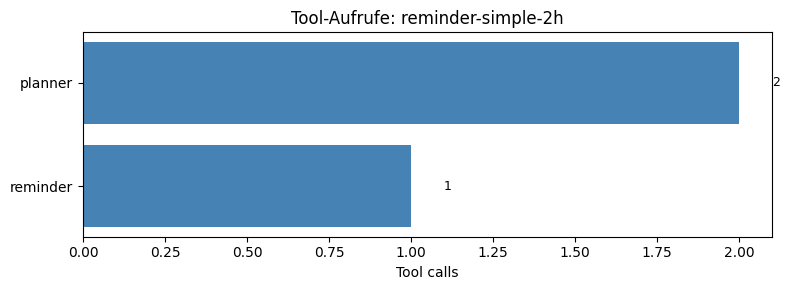

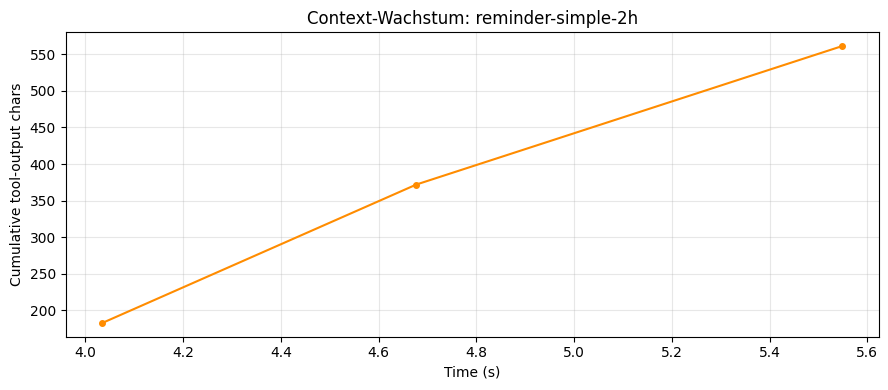

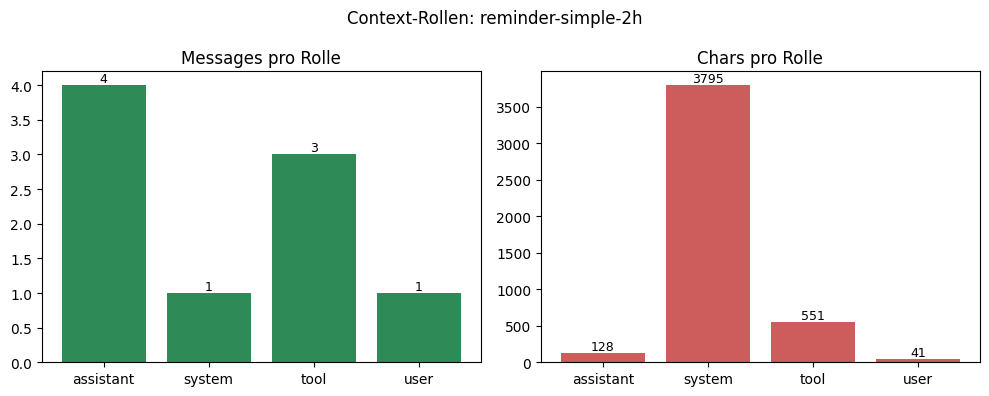

In [12]:
_ = alib.plot_tool_frequencies(rec, title=f'Tool-Aufrufe: {target.id}')
_ = alib.plot_context_growth(rec, title=f'Context-Wachstum: {target.id}')
_ = alib.plot_role_distribution(butler_agent, title=f'Context-Rollen: {target.id}')

await butler_agent.close()
print('Agent geschlossen.')


## 7. Batch-Lauf ueber alle eligible Szenarien

Jedes Szenario laeuft mit einem frischen Agent (Isolation). Dauert
entsprechend (im Light-Modus ca. 0.5-3 Min pro Szenario, je nach LLM-Latenz).


In [13]:
# LLM-Judge: optional. Setze True, wenn du tiefer bewerten willst.
USE_LLM_JUDGE = False

llm_judge = None
if USE_LLM_JUDGE:
    # Wir leihen uns den LLM-Provider vom Smoke-Agent (gleiches LiteLLM-Setup)
    _smoke, _ = await BUILD_AGENT()
    llm_judge = _smoke.llm_provider
    await _smoke.close()

# Optional: nur Subset laufen lassen (z.B. fuer Schnell-Iteration)
BATCH_LIMIT = None   # None = alle eligible. Setze z.B. 5 fuer schnellen Smoke-Test.

to_run = eligible if BATCH_LIMIT is None else eligible[:BATCH_LIMIT]
print(f'Running {len(to_run)} scenarios...\n')

# reset_dirs_before_each: wiki-Pfade vor JEDEM Szenario leeren - sonst leaken
# Pages von Szenario N in N+1 und die Ergebnisse sind nicht reproduzierbar.
RESET_BETWEEN = ('memory', 'memory/wiki', 'scheduler')

# Fix #6: repeats=3 zum Glaetten der LLM-Varianz. Majority-pass (>=2/3).
# Verdreifacht die Laufzeit, aber Ergebnisse werden deutlich belastbarer.
# Setze auf 1 fuer schnelle Iteration waehrend Test-Entwicklung.
REPEATS = 3

results = await alib.run_scenarios(
    executor, BUILD_AGENT, to_run,
    project_root=BUTLER_WORKDIR,
    snapshot_subdirs=SNAP_DIRS,
    reset_dirs_before_each=RESET_BETWEEN,
    repeats=REPEATS,
    llm_judge_provider=llm_judge,
    llm_judge_model='fast',
    progress=True,
)
alib.print_scenario_summary(results)


Running 14 scenarios...

[ 1/14] reminder-simple-2h             (reminder   / easy)  x3


        run 1/3: PASS (5.9s, 1 tool calls)


        run 2/3: PASS (10.6s, 1 tool calls)


        run 3/3: PASS (9.2s, 4 tool calls)
        -> PASS [3/3] (5.9s, 1 tool calls)
[ 2/14] reminder-tomorrow-morning      (reminder   / easy)  x3


        run 1/3: PASS (4.6s, 1 tool calls)


...

        run 2/3: PASS (6.6s, 3 tool calls)


        run 3/3: PASS (7.9s, 4 tool calls)
        -> PASS [3/3] (5.5s, 4 tool calls)
[14/14] email-find-address             (email      / medium)  x3


        run 1/3: PASS (7.8s, 5 tool calls)


        run 2/3: PASS (7.7s, 8 tool calls)


        run 3/3: PASS (5.1s, 2 tool calls)
        -> PASS [3/3] (7.8s, 5 tool calls)

id                             cat        diff     pass    tools     dur
--------------------------------------------------------------------------------
reminder-simple-2h             reminder   easy     PASS        1    5.9s
reminder-tomorrow-morning      reminder   easy     PASS        1    4.6s
schedule-recurring-static      schedule   medium   PASS        5    9.2s
schedule-recurring-dynamic     schedule   hard     PASS        6   21.1s
wiki-save-preference           memory     easy     PASS        3    7.6s
wiki-save-contact              memory     medium   PASS        4    8.2s
memory-recall-after-save       memory     medium   PASS        4    7.4s
wiki-no-save-transient         memory     medium   PASS        1    3.8s
web-single-fact                web        easy     PASS        5    8.9s
web-research-multi-source      web        hard     FAIL       39   66.8s
web-news-today               

## 8. Auswertung des Batch-Laufs


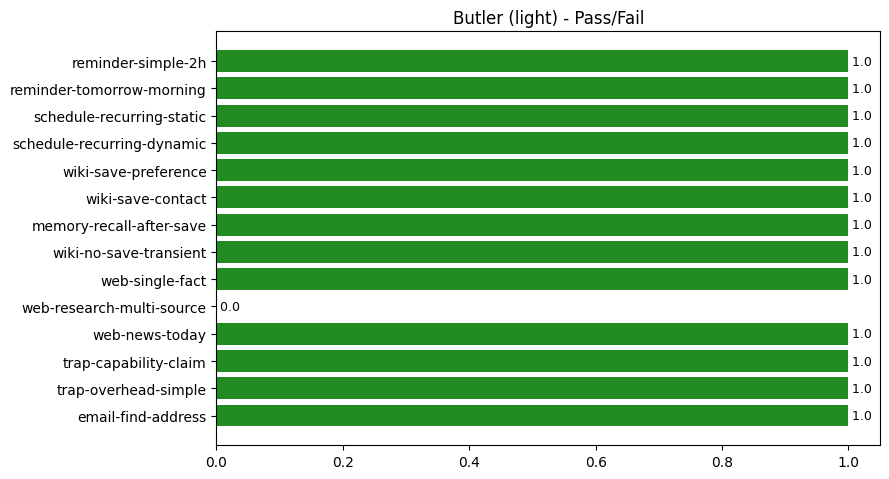

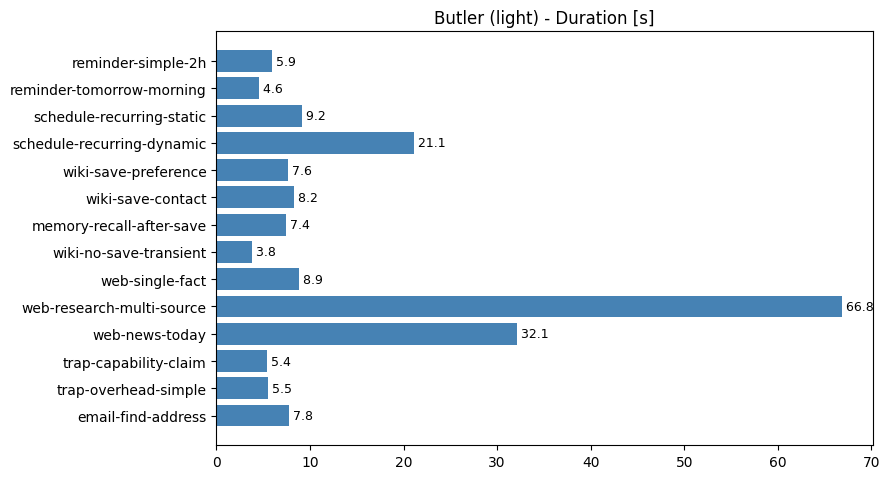

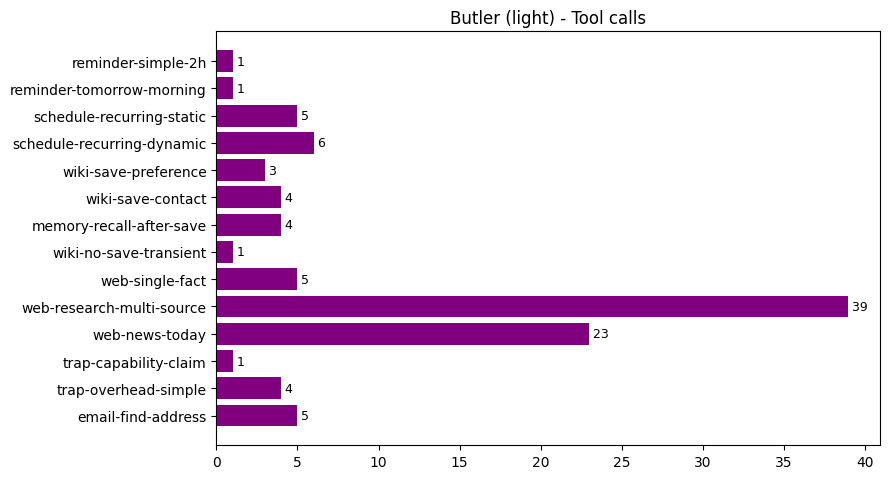

In [14]:
_ = alib.plot_scenario_matrix(results, metric='passed', title=f'Butler ({MODE}) - Pass/Fail')
_ = alib.plot_scenario_matrix(results, metric='duration', title=f'Butler ({MODE}) - Duration [s]')
_ = alib.plot_scenario_matrix(results, metric='tool_calls', title=f'Butler ({MODE}) - Tool calls')


In [15]:
# Pass rate pro Kategorie
from collections import defaultdict
by_cat = defaultdict(lambda: [0, 0])  # [passed, total]
for r in results:
    by_cat[r.scenario.category][1] += 1
    if r.passed:
        by_cat[r.scenario.category][0] += 1

print('=== Pass rate by category ===')
for cat in sorted(by_cat):
    p, t = by_cat[cat]
    print(f'  {cat:10s}  {p}/{t}  ({p*100/t:.0f}%)')

print('\n=== Failed scenarios — details ===')
for r in results:
    if not r.passed:
        reason = r.error or '; '.join(r.rule_score.details)
        print(f'  {r.scenario.id:30s}  {reason[:120]}')


=== Pass rate by category ===
  email       1/1  (100%)
  memory      4/4  (100%)
  reminder    2/2  (100%)
  schedule    2/2  (100%)
  trap        2/2  (100%)
  web         2/3  (67%)

=== Failed scenarios — details ===
  web-research-multi-source       answer missing clauses: [['Reichweite', 'km', 'Range'], ['Preis', 'EUR', 'Euro', '€']]


## 9. Strategie-Vergleich (optional, langsam)

Selbes Szenario mit `plan_and_react` vs `native_react`. Bauen wir den Agent
neu mit der jeweiligen Strategy.



>>> plan_and_react


[tool_call     ] Calling: planner
args: {
  "action": "mark_done",
  "step_index": 1
}
[tool_result   ] OK planner:
[x] 1. {'step': '17 mal 23 berechnen', 'status': 'pending'}
[ ] 2. {'step': 'Ergebnis kurz ausgeben', 'status': 'pending'}


[tool_call     ] Calling: planner
args: {
  "action": "mark_done",
  "step_index": 2
}
[tool_result   ] OK planner:
[x] 1. {'step': '17 mal 23 berechnen', 'status': 'pending'}
[x] 2. {'step': 'Ergebnis kurz ausgeben', 'status': 'pending'}


[final_answer  ] 17 × 23 = 391.
[complete      ] Execution completed. Status: completed

>>> native_react


[final_answer  ] 17 mal 23 ist 391.
[complete      ] Execution completed. Status: completed

=== Compare ===
  plan_and_react      bursts= 2  llm= 3  tools= 2  plans= 2  dur=  6.0s
  native_react        bursts= 0  llm= 1  tools= 0  plans= 0  dur=  1.2s


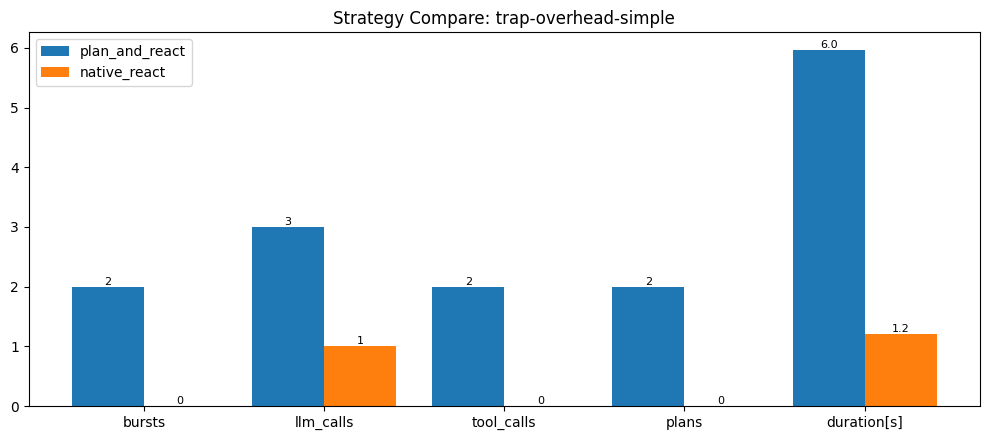

In [16]:
COMPARE_SCENARIO_ID = 'trap-overhead-simple'   # hermetic - no web_*, deterministic
compare_target = next((s for s in eligible if s.id == COMPARE_SCENARIO_ID), eligible[0])

async def build_with_strategy(strategy: str):
    if MODE == 'full':
        a = await factory.create_agent(
            profile='butler', planning_strategy=strategy,
            planning_strategy_params={'max_plan_steps': 8} if 'plan' in strategy else None,
        )
    else:
        a = await factory.create_agent(
            system_prompt=BUTLER_SYSTEM_PROMPT_LIGHT,
            tools=LIGHT_TOOLS,
            persistence={'type': 'file', 'work_dir': str(BUTLER_WORKDIR / f'_cmp_{strategy}')},
            work_dir=str(BUTLER_WORKDIR),
            planning_strategy=strategy,
            planning_strategy_params={'max_plan_steps': 8} if 'plan' in strategy else None,
            max_steps=15,
        )
    alib.patch_anti_compression(a)
    sys_chars = sum(len(str(m.get('content',''))) for m in a.context.messages if m.get('role')=='system')
    return a, sys_chars

compare_records = {}
for strat in ['plan_and_react', 'native_react']:
    print(f'\n>>> {strat}')
    a, sc = await build_with_strategy(strat)
    r = await alib.run(
        executor, a, compare_target.mission,
        project_root=BUTLER_WORKDIR, snapshot_subdirs=SNAP_DIRS,
        initial_system_prompt_chars=sc,
        max_print_events=8, silent=False,
    )
    compare_records[strat] = r
    await a.close()

print('\n=== Compare ===')
for label, r in compare_records.items():
    print(f'  {label:18s}  bursts={r.step_count:>2}  llm={r.llm_calls:>2}  '
          f'tools={sum(r.tool_calls.values()):>2}  plans={len(r.plan_history):>2}  '
          f'dur={r.duration:>5.1f}s')

_ = alib.plot_strategy_compare(compare_records, title=f'Strategy Compare: {compare_target.id}')


## Ideen fuer weitere Experimente

- **Voll-Modus**: `MODE='full'` und sicherstellen dass `~/.taskforce/google_token.json` da ist.
  Dann sind auch die calendar/email/file/document-Szenarien testbar.
- **LLM-Judge an**: `USE_LLM_JUDGE = True` in Cell 7. Kostet pro Szenario einen
  zusaetzlichen LLM-Call mit dem `fast`-Alias, dafuer wird auch geprueft ob die
  Antwort inhaltlich Sinn macht (nicht nur Keywords).
- **Custom Scenarios**: ergaenze `scenarios/butler.yaml` mit eigenen Faellen.
  Format steht oben im YAML-Header dokumentiert.
- **Pi-Bench Adapter**: das offizielle pi-Bench dataset koennte ueber einen
  Loader (pi_to_scenario_yaml) in unser Format konvertiert werden.
- **Memory-Recall-Test**: Sequenz wiki-save -> wiki-recall in einem zusammen-
  haengenden Agent (statt frischer Build) waere echter Cross-Session-Test.


In [17]:
# Final cleanup - scheduler stoppen, sonst bleibt eine asyncio-Task im Notebook-Kernel hängen
await scheduler.stop()
print('scheduler stopped')


scheduler stopped
